## **Source Code**

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "#f5f5f5"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
%matplotlib inline

print("Setup complete. You can start the experiment.")

Setup complete. You can start the experiment.


In [31]:
# Load the Breast Cancer dataset
data = load_breast_cancer(as_frame=True)
features = data.frame.drop(columns=["target"])
target = data.frame["target"]

print("Shape:", features.shape)
print("Class counts:\n", target.value_counts())
print("Target names:", data.target_names)

Shape: (569, 30)
Class counts:
 target
1    357
0    212
Name: count, dtype: int64
Target names: ['malignant' 'benign']


In [32]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target,
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


In [33]:
# Train Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Initialize the classifier
dt_model = DecisionTreeClassifier(
    criterion="entropy",      # Splitting criterion: "gini" or "entropy"
    max_depth=3,           # Maximum depth of the tree
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [34]:
# Display model information

print("Criterion      :", dt_model.criterion)
print("Maximum Depth  :", dt_model.max_depth)
print("Tree Depth     :", dt_model.get_depth())
print("Leaf Nodes     :", dt_model.get_n_leaves())

Criterion      : entropy
Maximum Depth  : 3
Tree Depth     : 3
Leaf Nodes     : 7


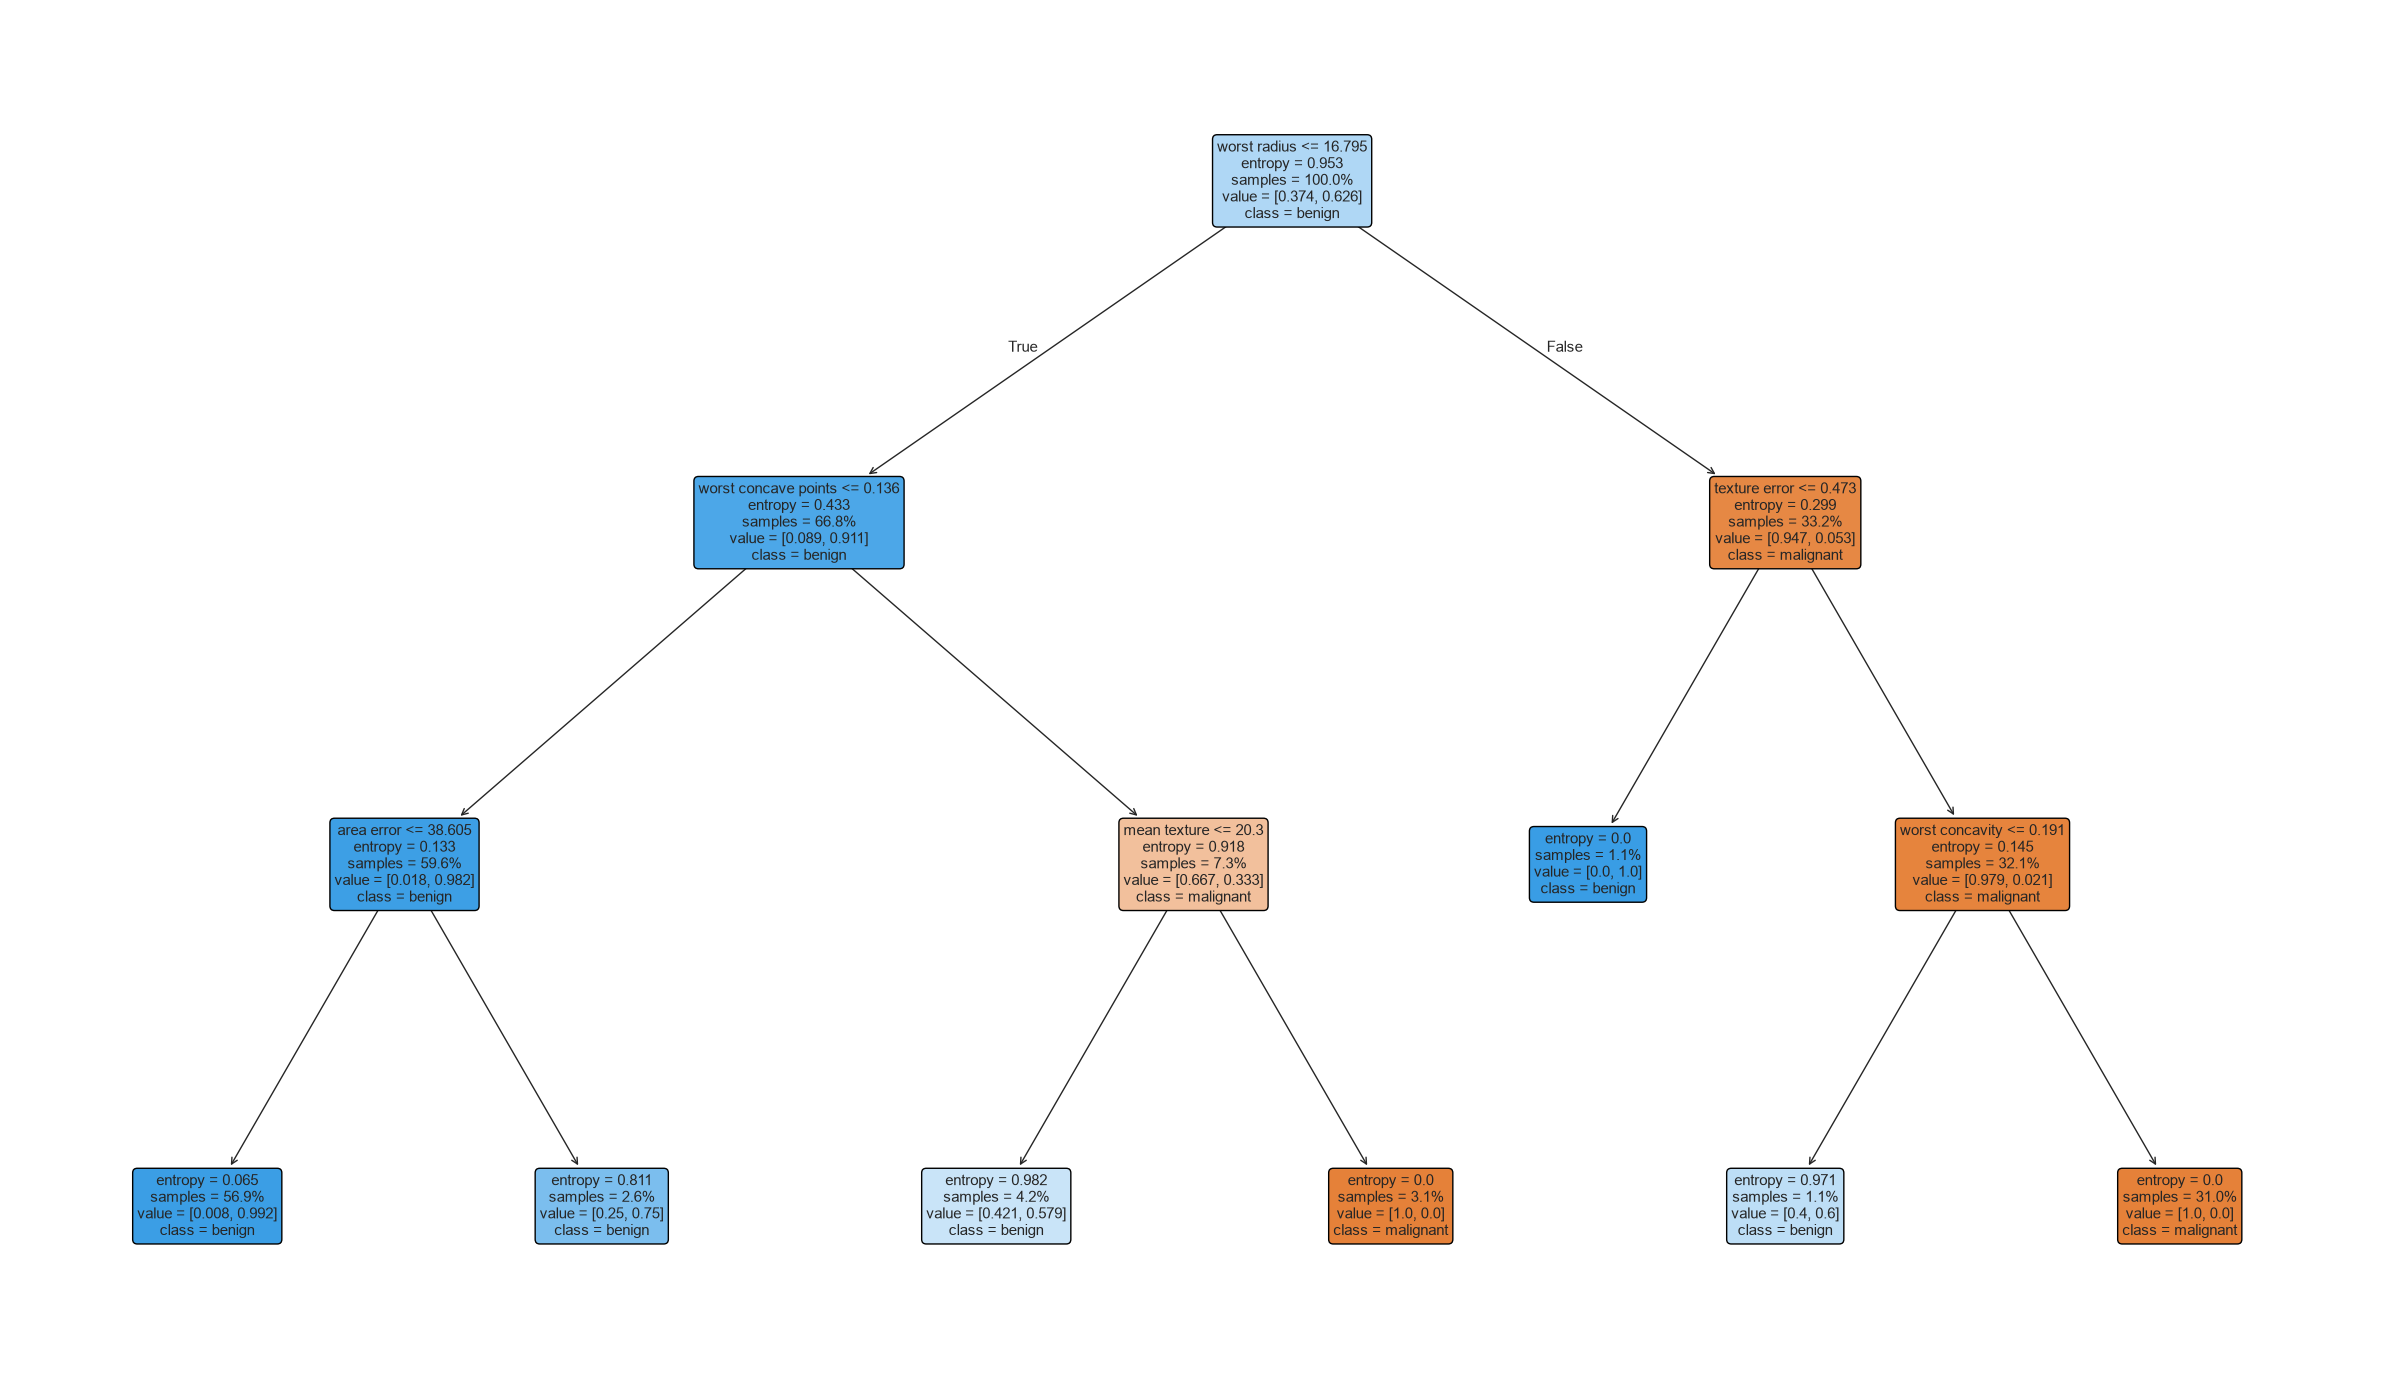

In [35]:
# Visualize the Decision Tree

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(24, 14), facecolor="white")

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=11,
    proportion=True,
    ax=ax,
    impurity=True
)

plt.tight_layout()
plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [36]:
# Make Predictions

# Predict class labels
y_pred_dt = dt_model.predict(X_test)

# Display first 10 predictions
dt_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt
})

dt_prediction_df.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [37]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy : {dt_accuracy:.4f}")

Accuracy : 0.9474


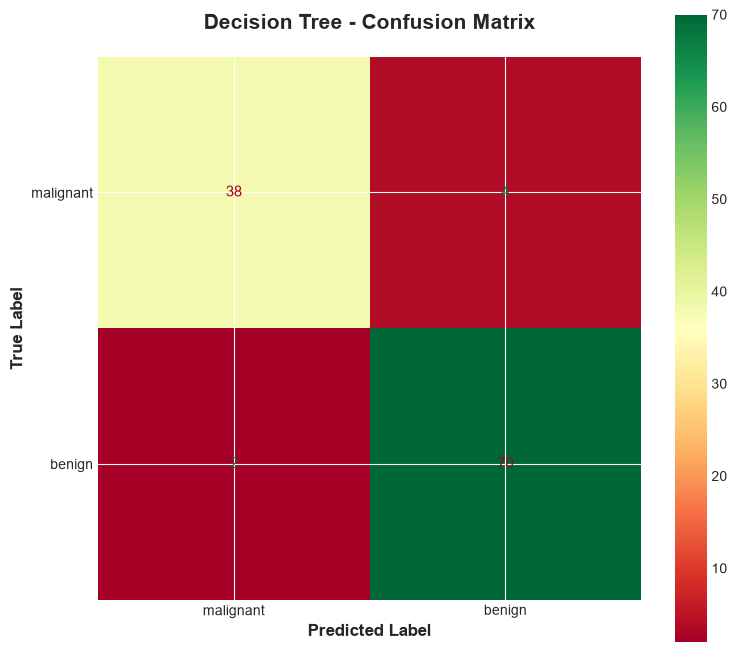

In [38]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[data.target_names[0], data.target_names[1]]
)

fig, ax = plt.subplots(figsize=(8, 7), facecolor="white")
disp.plot(cmap="RdYlGn", ax=ax, colorbar=True, values_format="d")

ax.set_title("Decision Tree - Confusion Matrix", fontsize=15, fontweight="bold", pad=20)
ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
ax.set_ylabel("True Label", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [39]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



,Feature,Importance
20,worst radius,0.670365
27,worst concave points,0.170025
11,texture error,0.062660
26,worst concavity,0.042339
1,mean texture,0.030358
13,area error,0.024252
5,mean compactness,0.000000
4,mean smoothness,0.000000
6,mean concavity,0.000000
7,mean concave points,0.000000


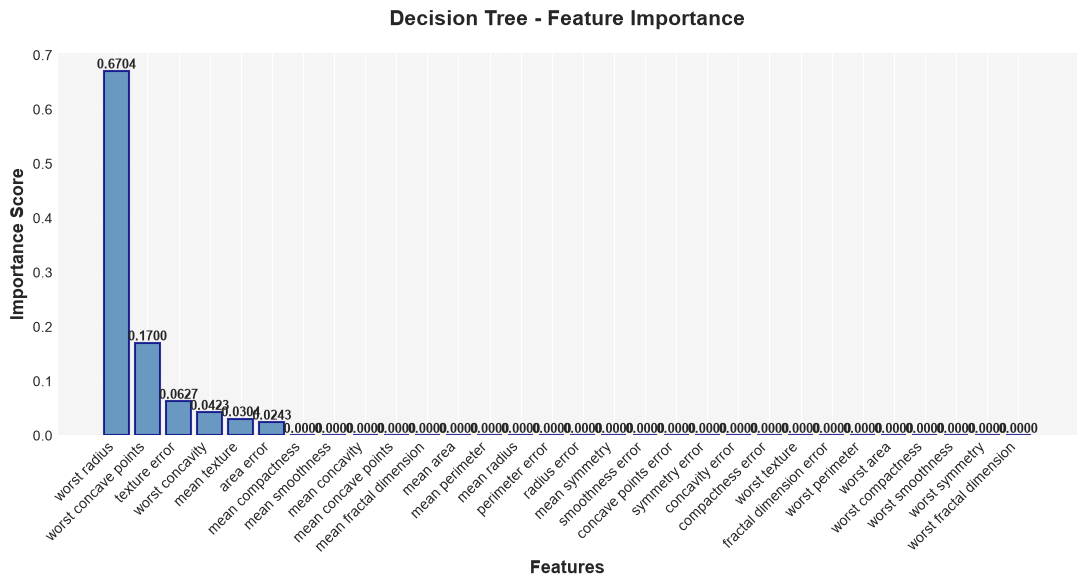

In [40]:
# Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")
bars = ax.bar(
    importance["Feature"],
    importance["Importance"],
    color="steelblue",
    edgecolor="navy",
    linewidth=1.5,
    alpha=0.8
)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight="bold")

ax.set_xlabel("Features", fontsize=13, fontweight="bold")
ax.set_ylabel("Importance Score", fontsize=13, fontweight="bold")
ax.set_title("Decision Tree - Feature Importance", fontsize=15, fontweight="bold", pad=20)
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [41]:
# Train K-Nearest Neighbors (KNN) Classifier

from sklearn.neighbors import KNeighborsClassifier

# Initialize the classifier
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric="minkowski",
    p=2      # Euclidean Distance
)

# Train the model
knn_model.fit(X_train, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [42]:
# Display Model Information

print("Number of Neighbors (K):", knn_model.n_neighbors)
print("Distance Metric        :", knn_model.metric)
print("Power Parameter (p)    :", knn_model.p)

Number of Neighbors (K): 5
Distance Metric        : minkowski
Power Parameter (p)    : 2


In [43]:
# Make Predictions

# Predict class labels
y_pred_knn = knn_model.predict(X_test)

# Display first 10 predictions
knn_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_knn
})

knn_prediction_df.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,0
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [44]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy : {knn_accuracy:.4f}")

KNN Accuracy : 0.9123


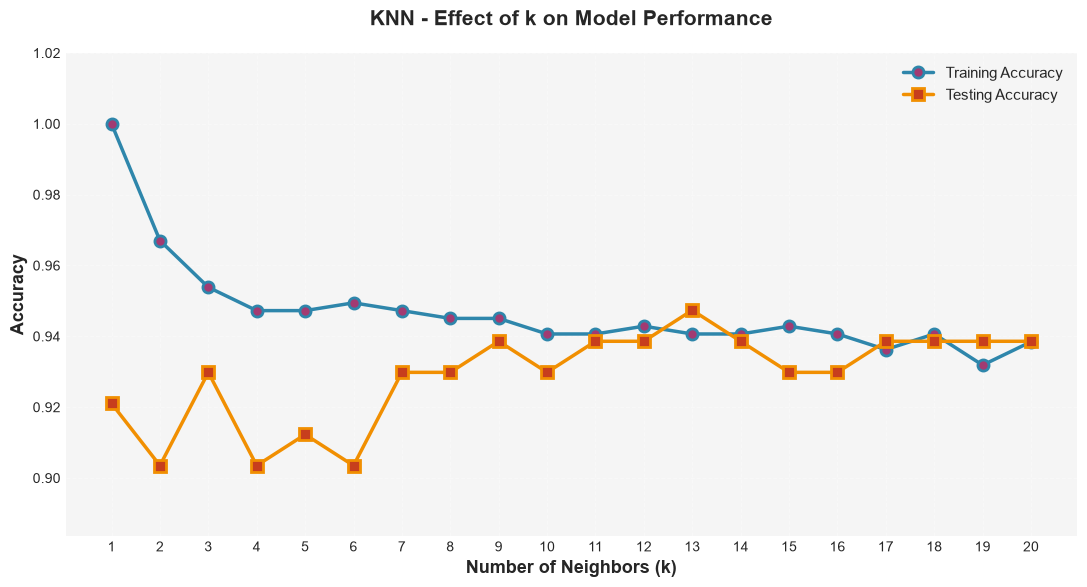

In [45]:
# Effect of Choosing K

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = range(1, 21)
train_accuracy = []
test_accuracy = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train model
    knn.fit(X_train, y_train)

    # Training accuracy
    train_pred = knn.predict(X_train)
    train_accuracy.append(accuracy_score(y_train, train_pred))

    # Testing accuracy
    test_pred = knn.predict(X_test)
    test_accuracy.append(accuracy_score(y_test, test_pred))
    
    
# Plotting the results

fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")

ax.plot(
    k_values,
    train_accuracy,
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Training Accuracy',
    color='#2E86AB',
    markerfacecolor='#A23B72',
    markeredgewidth=2,
    markeredgecolor='#2E86AB'
)

ax.plot(
    k_values,
    test_accuracy,
    marker='s',
    linewidth=2.5,
    markersize=8,
    label='Testing Accuracy',
    color='#F18F01',
    markerfacecolor='#C73E1D',
    markeredgewidth=2,
    markeredgecolor='#F18F01'
)

ax.set_xlabel("Number of Neighbors (k)", fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy", fontsize=13, fontweight="bold")
ax.set_title("KNN - Effect of k on Model Performance", fontsize=15, fontweight="bold", pad=20)
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=11, loc="best", framealpha=0.9)
ax.set_ylim([min(test_accuracy) - 0.02, 1.02])

plt.tight_layout()
plt.show()

In [46]:
# Train Gaussian Naïve Bayes Classifier

from sklearn.naive_bayes import GaussianNB

# Initialize the classifier
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Gaussian Naïve Bayes model trained successfully!")

Gaussian Naïve Bayes model trained successfully!


In [47]:
# Display Model Information

print("Model Type:", type(nb_model).__name__)
print("Class Prior Probabilities:")
print(nb_model.class_prior_)

Model Type: GaussianNB
Class Prior Probabilities:
[0.37362637 0.62637363]


In [48]:
# Make Predictions

# Predict class labels
y_pred_nb = nb_model.predict(X_test)

# Display first 10 predictions
nb_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_nb
})

nb_prediction_df.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [49]:
nv_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Gaussian Naïve Bayes Accuracy : {nv_accuracy:.4f}")

Gaussian Naïve Bayes Accuracy : 0.9386


In [50]:
# Learned Parameters

import pandas as pd

mean_df = pd.DataFrame(
    nb_model.theta_,
    columns=data.feature_names,
    index=data.target_names
)

display(mean_df)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
malignant,17.381235,21.579882,114.830647,966.820000,0.102994,0.146145,0.162363,0.087607,0.193631,0.062829,...,20.967059,29.276765,140.258176,1396.771176,0.144848,0.378882,0.463243,0.182847,0.326841,0.091737
benign,12.090428,17.856035,77.675123,458.690526,0.092095,0.078652,0.045548,0.024924,0.172856,0.062814,...,13.320133,23.482351,86.563579,554.231579,0.124862,0.180034,0.165234,0.072780,0.269406,0.079296


In [51]:
# Train Support Vector Machine (SVM) Classifier

from sklearn.svm import SVC

# Initialize the classifier
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

# Train the model
svm_model.fit(X_train, y_train)

print("Support Vector Machine model trained successfully!")

Support Vector Machine model trained successfully!


In [52]:
# Display Model Information

print("Kernel          :", svm_model.kernel)
print("Penalty (C)     :", svm_model.C)
print("Gamma           :", svm_model.gamma)
print("Support Vectors :", svm_model.n_support_)

Kernel          : rbf
Penalty (C)     : 1.0
Gamma           : scale
Support Vectors : [63 61]


In [53]:
# Make Predictions

# Predict class labels
y_pred_svm = svm_model.predict(X_test)

# Display first 10 predictions
svm_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_svm
})

svm_prediction_df.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,1
3,1,0
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [54]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Support Vector Machine Accuracy : {svm_accuracy:.4f}")

Support Vector Machine Accuracy : 0.9298


    Kernel  Training Accuracy  Testing Accuracy
0   linear           0.958242          0.956140
1     poly           0.909890          0.921053
2      rbf           0.918681          0.929825
3  sigmoid           0.461538          0.447368


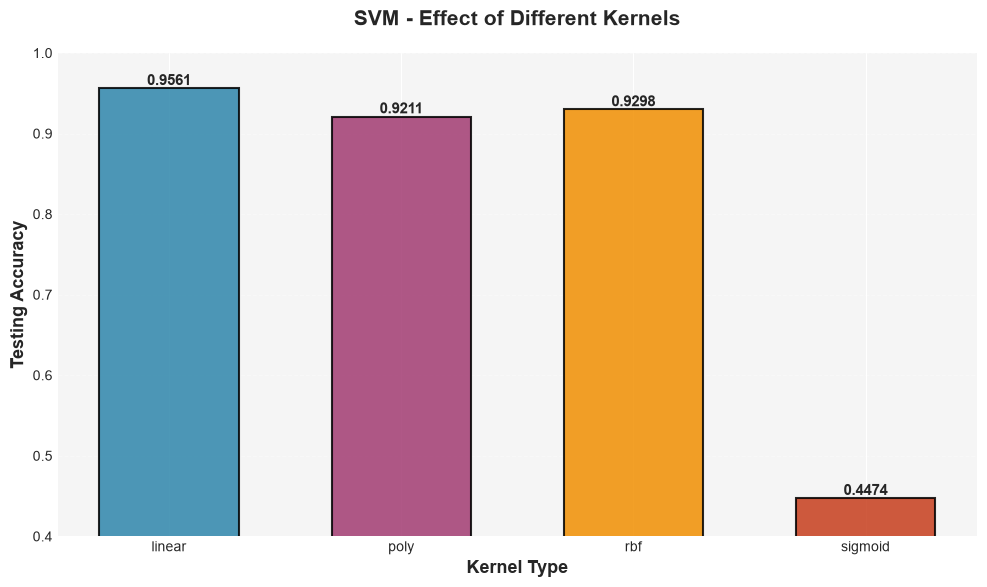

In [55]:
# Effect of Different Kernels

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

kernels = ["linear", "poly", "rbf", "sigmoid"]

results = []

for kernel in kernels:

    model = SVC(
        kernel=kernel,
        probability=True,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test,
        model.predict(X_test)
    )

    results.append([
        kernel,
        train_acc,
        test_acc
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Kernel",
        "Training Accuracy",
        "Testing Accuracy"
    ]
)

print(results)


# Visualize the Effect of Different Kernels

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")

colors_bar = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]
bars = ax.bar(
    results["Kernel"],
    results["Testing Accuracy"],
    color=colors_bar,
    edgecolor="black",
    linewidth=1.5,
    alpha=0.85,
    width=0.6
)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight="bold")

ax.set_ylabel("Testing Accuracy", fontsize=13, fontweight="bold")
ax.set_xlabel("Kernel Type", fontsize=13, fontweight="bold")
ax.set_title("SVM - Effect of Different Kernels", fontsize=15, fontweight="bold", pad=20)
ax.set_ylim([0.4, 1.0])
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### **Comparison**

In [56]:
# Compare All Models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd
from sklearn.preprocessing import label_binarize

models = {
    "Decision Tree": (dt_model, y_pred_dt),
    "KNN": (knn_model, y_pred_knn),
    "Naïve Bayes": (nb_model, y_pred_nb),
    "SVM": (svm_model, y_pred_svm)
}

comparison = []

for name, (model, y_pred) in models.items():

    auc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    comparison.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted"),
        auc_score
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ]
)

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.9474,0.9474,0.9474,0.9471,0.9448
1,KNN,0.9123,0.9137,0.9123,0.9127,0.9559
2,Naïve Bayes,0.9386,0.9384,0.9386,0.9384,0.9878
3,SVM,0.9298,0.9307,0.9298,0.9290,0.9696


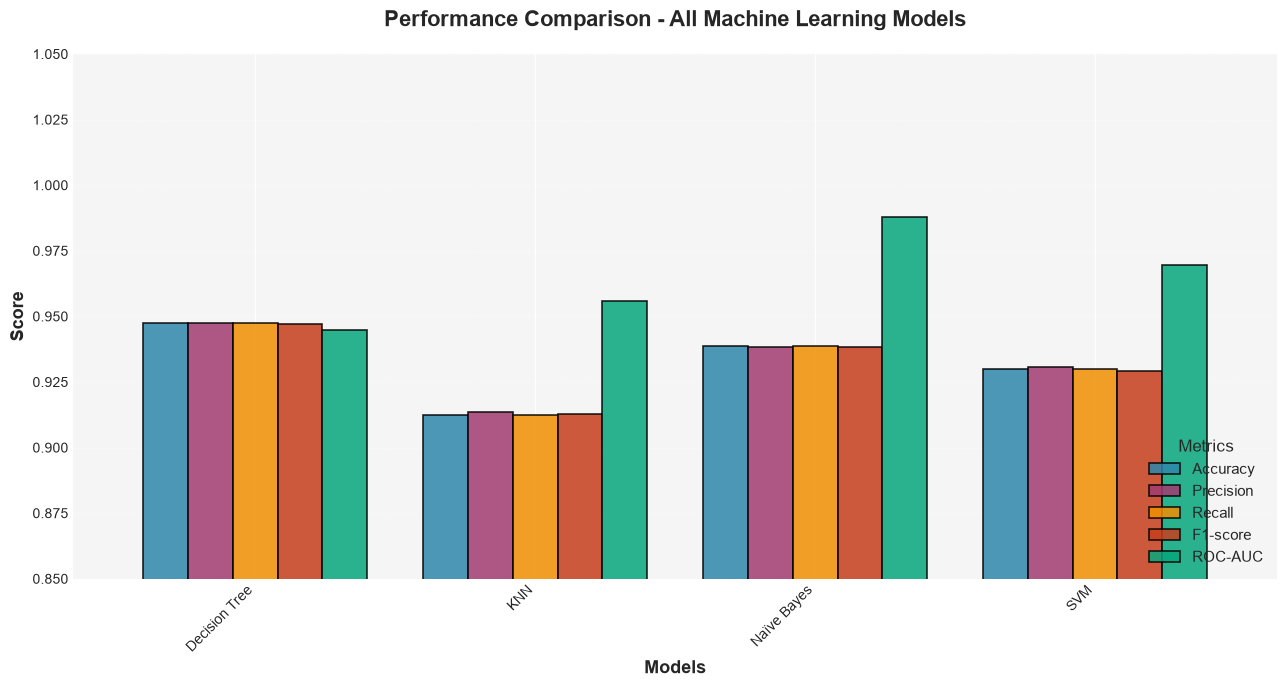

In [57]:
# Grouped Bar Chart of Performance Metrics

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")

comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
].plot(
    kind="bar",
    ax=ax,
    figsize=(13, 7),
    width=0.8,
    color=["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#06A77D"],
    edgecolor="black",
    linewidth=1.2,
    alpha=0.85
)

ax.set_title("Performance Comparison - All Machine Learning Models", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Models", fontsize=13, fontweight="bold")
ax.set_ylabel("Score", fontsize=13, fontweight="bold")
ax.set_ylim([0.85, 1.05])
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.legend(loc="lower right", fontsize=11, framealpha=0.95, title="Metrics", title_fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

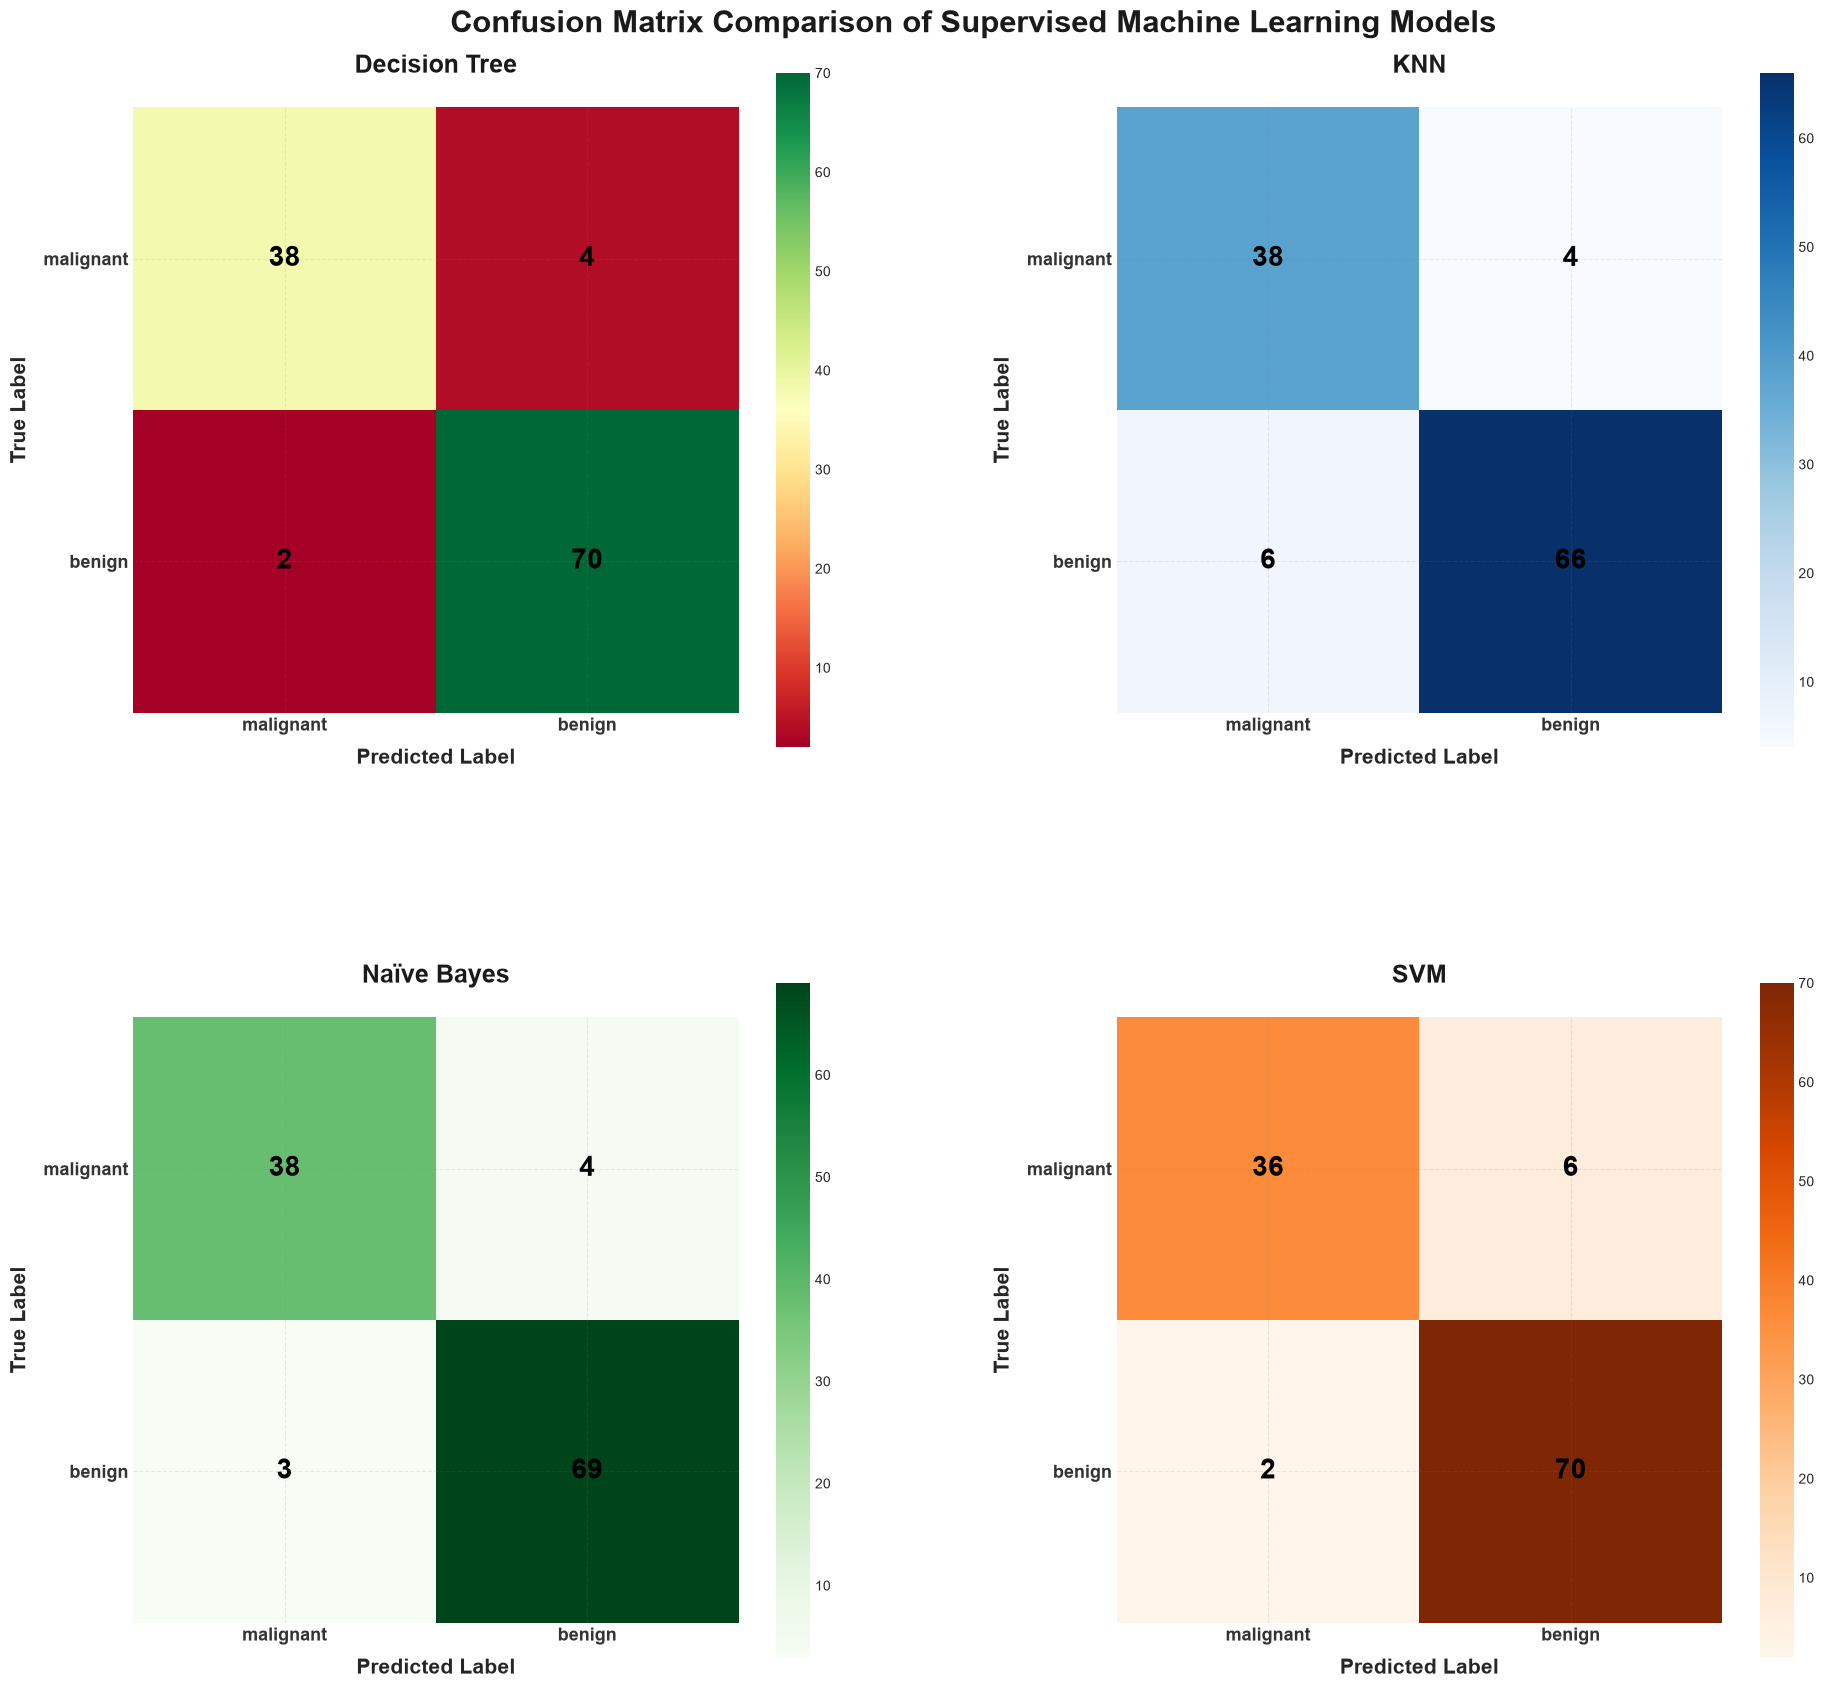

In [58]:
# Confusion Matrix Comparison

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Model names and predictions
models = {
    "Decision Tree": y_pred_dt,
    "KNN": y_pred_knn,
    "Naïve Bayes": y_pred_nb,
    "SVM": y_pred_svm
}

fig, axes = plt.subplots(2, 2, figsize=(20, 18), facecolor="white")

axes = axes.ravel()

colormaps_list = ["RdYlGn", "Blues", "Greens", "Oranges"]

for idx, (ax, (name, y_pred), cmap) in enumerate(zip(axes, models.items(), colormaps_list)):

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=data.target_names
    )

    disp.plot(
        ax=ax,
        cmap=cmap,
        colorbar=True,
        values_format="d",
        text_kw={"size": 20, "weight": "bold", "color": "black"}
    )

    # Enhance the appearance
    ax.set_title(f"{name}", fontsize=18, fontweight="bold", pad=25, color="#1a1a1a")
    ax.set_xlabel("Predicted Label", fontsize=15, fontweight="bold", labelpad=10)
    ax.set_ylabel("True Label", fontsize=15, fontweight="bold", labelpad=10)
    ax.tick_params(labelsize=13, colors="#333333")
    
    # Make tick labels bold
    for label in ax.get_xticklabels():
        label.set_weight("bold")
    for label in ax.get_yticklabels():
        label.set_weight("bold")
    
    # Add subtle grid
    ax.grid(True, alpha=0.15, linestyle="--", linewidth=0.8, color="gray")
    ax.set_axisbelow(True)
    
    # Enhance the colorbar
    if ax.collections:
        cbar = ax.collections[0].colorbar
        if cbar:
            cbar.ax.tick_params(labelsize=12, colors="#333333")
            cbar.set_label("Count", fontsize=13, fontweight="bold", labelpad=10)

plt.suptitle(
    "Confusion Matrix Comparison of Supervised Machine Learning Models",
    fontsize=22,
    fontweight="bold",
    y=0.995,
    color="#1a1a1a"
)

fig.subplots_adjust(left=0.08, right=0.95, top=0.96, bottom=0.08, hspace=0.35, wspace=0.30)
plt.show()